# Hourly Energy Consumption Forecasting: PJM Interconnection
Project Context
PJM Interconnection LLC (PJM) is a major regional transmission organization (RTO) in the United States, operating an electric transmission system that serves all or parts of 13 states and the District of Columbia.

Objective
The goal of this project is to build a robust machine learning model using XGBoost to forecast hourly electricity consumption (measured in Megawatts, MW). Accurate forecasting is critical for grid stability, resource planning, and optimizing operational costs.

Dataset
The dataset contains hourly power consumption records from the PJM website, providing a rich time-series history for training and validation.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Read Data
df = pd.read_csv('PJME_hourly.csv')

# 2. Convert Datetime field into datetime format and set Index
df['Datetime'] = pd.to_datetime(df['Datetime'])
df = df.set_index('Datetime')
df = df.sort_index() # ensure index in asending order

Data checking

In [24]:
# 1. Check for Missing values
print("Missing values count:")
print(df.isnull().sum())

# 2. Check for Duplicate Index
print(f"\nAre there duplicate timestamps? {df.index.duplicated().any()}")

# 3. Check for gaps in time
# As Hourly interval is expected, Check for interval between Index
expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')
missing_dates = expected_range.difference(df.index)
print(f"\nNumber of missing hours in the sequence: {len(missing_dates)}")

# 4. Data statistics
print("\nData Statistics:")
print(df.describe())

Missing values count:
PJME_MW    0
dtype: int64

Are there duplicate timestamps? True

Number of missing hours in the sequence: 30

Data Statistics:
             PJME_MW
count  145366.000000
mean    32080.222831
std      6464.012166
min     14544.000000
25%     27573.000000
50%     31421.000000
75%     35650.000000
max     62009.000000


C:\Users\Alex\AppData\Local\Temp\ipykernel_7248\387118359.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  expected_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='H')


## Data Integrity & Preprocessing
Raw time-series data often contains anomalies due to daylight saving adjustments or sensor errors. In this section, I performed:

Duplicate Removal: Identified and resolved overlapping timestamps to ensure a continuous chronological sequence.

Missing Value Treatment: Handled gaps in the series caused by the shift() operation during feature engineering to ensure model stability.

In [25]:
# Remove duplicate timestamps with group Mean
df = df.groupby(df.index).mean()

# Check for Duplicate Index
print(f"Are there duplicate timestamps now? {df.index.duplicated().any()}")

Are there duplicate timestamps now? False


Gap Filling
The loss of 30 hour data lead the broken line in line graph and create error in Rolling. Using Linear Interpolation to fill the gaps .

In [26]:
# Rebuild index in Hourly basis, NaN reading in the 30 gaps 
df = df.reindex(expected_range)

# Fill NaN by linear interpolation 
df['PJME_MW'] = df['PJME_MW'].interpolate(method='linear')

# Check for gaps in time
print(f"Missing values count after interpolation: {df['PJME_MW'].isnull().sum()}")

Missing values count after interpolation: 0


## Feature Engineering: Extracting Temporal Patterns
Time-series data inherently contains seasonal and cyclical patterns. To enable the Gradient Boosting model to capture these nuances, I have engineered several features from the timestamp index:

Hour & Day of Week: Captures intraday and weekly cycles (e.g., workday vs. weekend usage).

Month & Quarter: Captures seasonal shifts driven by climate (e.g., heating in winter, cooling in summer).

Day of Year: Provides a high-resolution view of annual seasonality.

In [27]:
def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['quarter'] = df.index.quarter
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofyear'] = df.index.dayofyear
    return df

df = create_features(df)

# Check if time features value
print(df.head())

                     PJME_MW  hour  dayofweek  quarter  month  year  dayofyear
2002-01-01 01:00:00  30393.0     1          1        1      1  2002          1
2002-01-01 02:00:00  29265.0     2          1        1      1  2002          1
2002-01-01 03:00:00  28357.0     3          1        1      1  2002          1
2002-01-01 04:00:00  27899.0     4          1        1      1  2002          1
2002-01-01 05:00:00  28057.0     5          1        1      1  2002          1


Hourly electric usage box plot

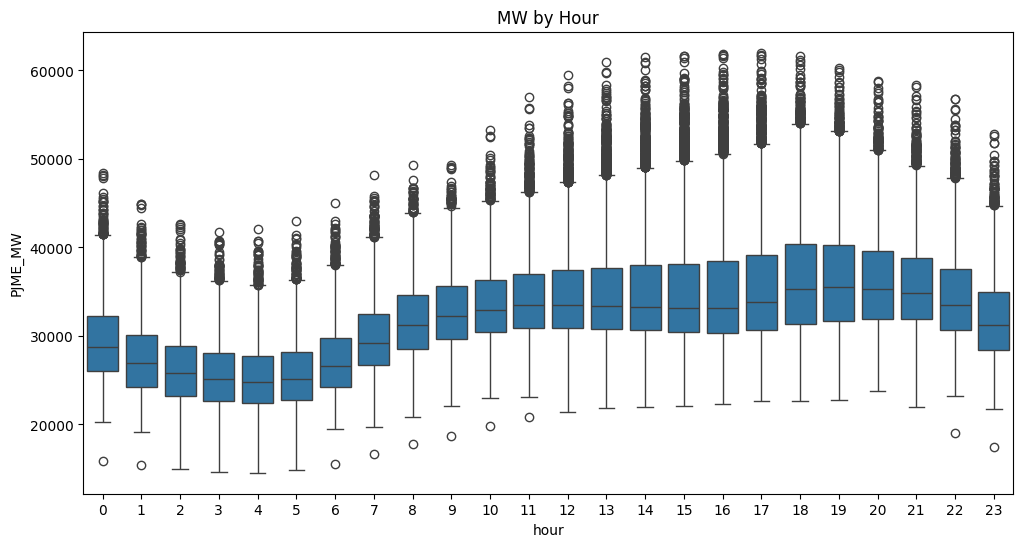

In [28]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='hour', y='PJME_MW')
plt.title('MW by Hour')
plt.show()

The graph shows the electric usage were peaks between 18:00 to 20:00, while low between 1:00 to 6:00. Electric company can use Time-of-Use Pricing to encourage customer shift their unnecessary electric usage to low loading peroid to achieve Load Balancing.

Monthly electric usage box plot

C:\Users\Alex\AppData\Local\Temp\ipykernel_7248\2013033296.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='PJME_MW', palette='viridis')


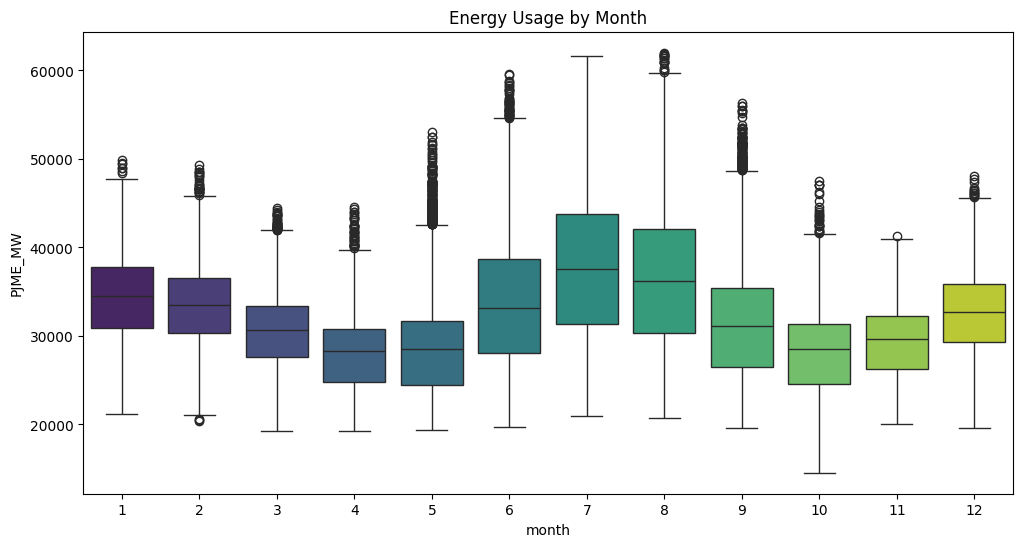

In [29]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='month', y='PJME_MW', palette='viridis')
plt.title('Energy Usage by Month')
plt.show()

The graph shows peak energy usage in both summer and winter, air conditioning and heating are hightly demanded respectively.
Off peak months are April and May, electric company could undergo scalable maintance or enhancement to ensure stablity in coming peak months. 

## Lag Features study: compare electric usage and electric usage(py) 

In [30]:
# Create lag features for same hour previous year (24 hour * 365 day = 8760)
df['lag_1year'] = df['PJME_MW'].shift(8760)

# compare
print(df[['PJME_MW', 'lag_1year']].tail())

                     PJME_MW  lag_1year
2018-08-02 20:00:00  44057.0    39352.0
2018-08-02 21:00:00  43256.0    38699.0
2018-08-02 22:00:00  41552.0    37346.0
2018-08-02 23:00:00  38500.0    34555.0
2018-08-03 00:00:00  35486.0    31646.0


Train / Test Split

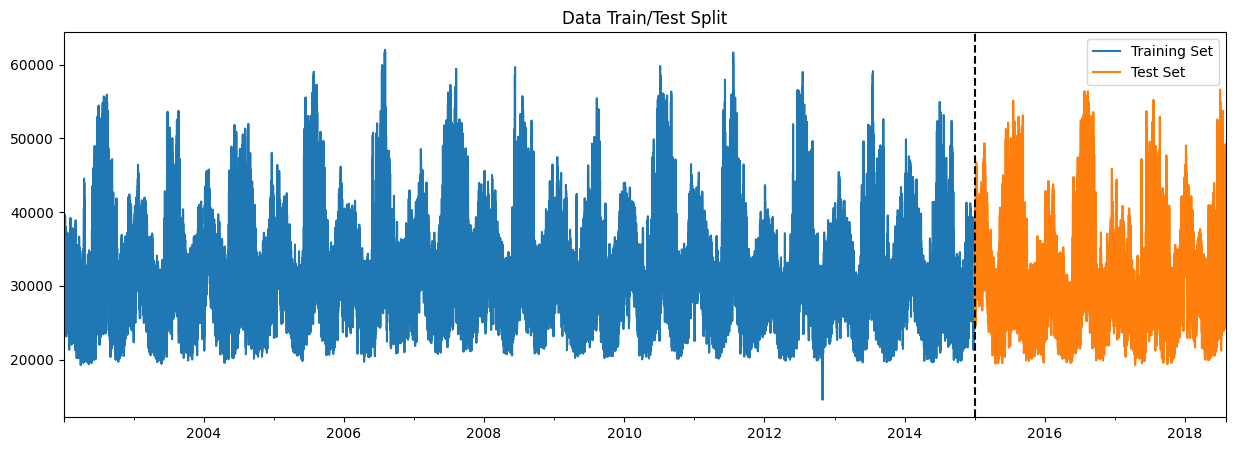

In [31]:
# split at 2015-01-01
train = df.loc[df.index < '2015-01-01']
test = df.loc[df.index >= '2015-01-01']

# plot both series
fig, ax = plt.subplots(figsize=(15, 5))
train['PJME_MW'].plot(ax=ax, label='Training Set', title='Data Train/Test Split')
test['PJME_MW'].plot(ax=ax, label='Test Set')
ax.axvline('2015-01-01', color='black', ls='--')
ax.legend(['Training Set', 'Test Set'])
plt.show()

Mechine Learning(ML)=Regression:
Forecast PJME_MW by hour, dayofweek, month, year features

In [32]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error

# Set Features and Target
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear']
TARGET = 'PJME_MW'

X_train = train[FEATURES]
y_train = train[TARGET]

X_test = test[FEATURES]
y_test = test[TARGET]

# Build XGBoost regression model
reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)

# Training with Validation Set prevent Overfitting
reg.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:32603.50613	validation_1-rmse:31657.42430


c:\Users\Alex\AppData\Local\Programs\Python\Python312\Lib\site-packages\xgboost\callback.py:385: UserWarning: [15:21:22] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  self.starting_round = model.num_boosted_rounds()


[100]	validation_0-rmse:12580.56894	validation_1-rmse:11742.95563
[200]	validation_0-rmse:5837.98773	validation_1-rmse:5365.82763
[300]	validation_0-rmse:3925.89160	validation_1-rmse:4020.84427
[400]	validation_0-rmse:3448.54976	validation_1-rmse:3861.35063
[500]	validation_0-rmse:3289.79649	validation_1-rmse:3816.33147
[600]	validation_0-rmse:3207.88488	validation_1-rmse:3776.74993
[700]	validation_0-rmse:3153.29527	validation_1-rmse:3756.39433
[800]	validation_0-rmse:3114.25136	validation_1-rmse:3738.25611
[900]	validation_0-rmse:3084.66276	validation_1-rmse:3729.58268
[999]	validation_0-rmse:3058.15989	validation_1-rmse:3727.13986


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

The RMSR of test model decrease only 2 in 900th to 999th trial means this model set up reach its "best-fitting".
And the RMSR=3727mw is around 10% of the expected value(30 000~40 000mw), it can be use for electric usage prediction.

Investigate importance of features to electric usage 

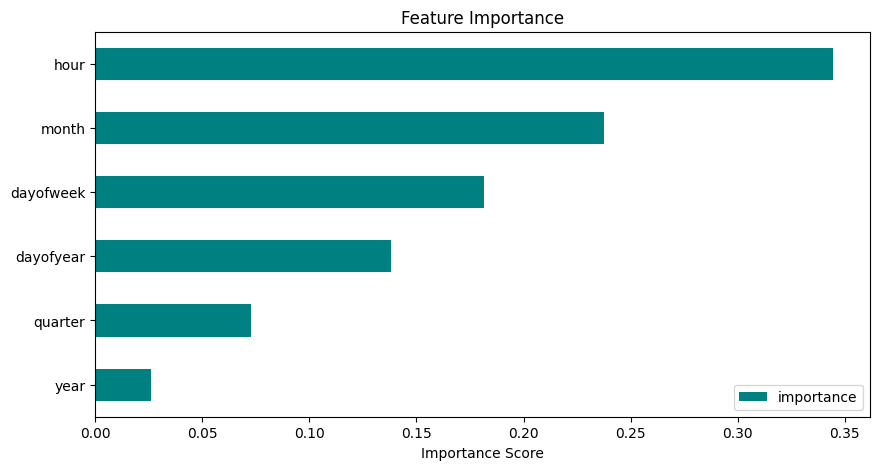

In [33]:
# 1. Create a DataFrame to store Name and co-effient of features in regression model
fi = pd.DataFrame(data=reg.feature_importances_,
             index=reg.feature_names_in_,
             columns=['importance'])

# 2. Sorting and plot
fi.sort_values('importance').plot(kind='barh', title='Feature Importance', figsize=(10, 5), color='teal')
plt.xlabel('Importance Score')
plt.show()

The graph show Hour is the most importance feature, because electric usage is highly sensitive in daily activities that reflected in hour base. Then following by Month, which align with different usage pattern in each season. The Day of week also a significant feature since there are diffenent usage pattern in commerical, industial and household activities. While Year is not an importance factor impilies the area without significant development in past years.  

## Model Evaluation

C:\Users\Alex\AppData\Local\Temp\ipykernel_7248\674247268.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg.predict(X_test)


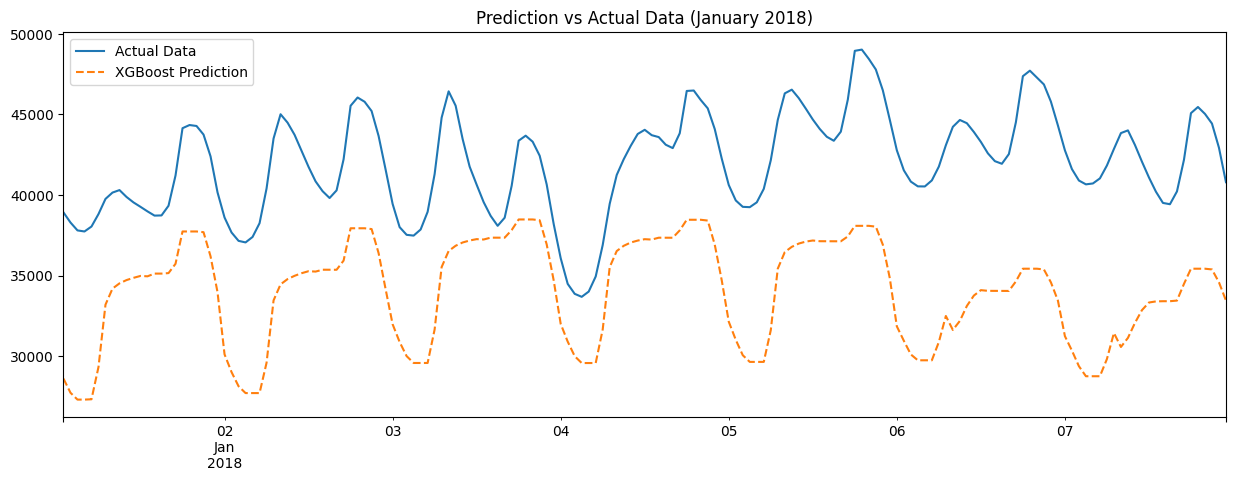

In [34]:
# 1. Put features in test set
test['prediction'] = reg.predict(X_test)

# 2. Combin the Test set with df
df_all = pd.concat([df, test[['prediction']]], axis=1)

# 3. Compare actural and predict value in 2018-01-01 to 2018-01-08
ax = df_all.loc[(df_all.index > '2018-01-01') & (df_all.index < '2018-01-08')]['PJME_MW'] \
    .plot(figsize=(15, 5), title='Prediction vs Actual Data (January 2018)')
df_all.loc[(df_all.index > '2018-01-01') & (df_all.index < '2018-01-08')]['prediction'] \
    .plot(ax=ax, style='--')

plt.legend(['Actual Data', 'XGBoost Prediction'])
plt.show()

Initial Baseline Evaluation
The preliminary model using only temporal features (hour, day, etc.) provided a baseline for the general consumption trend.

Key Finding: While the model captures the "rhythm" of the grid, it exhibits a significant under-estimation (approx. 8,000 MW) during extreme peak periods. This suggests that calendar-based features alone cannot account for the full volatility of energy demand, necessitating more advanced feature engineering.

Incorporating Autoregression: Lag Features
To address the limitations of the baseline model, I introduced a 24-hour Lag Feature (lag_24h).

Rationale: Energy consumption is highly autocorrelated—what happened at 5 PM yesterday is often the strongest predictor for 5 PM today. By including the previous day's load, the model can adjust to recent shifts in baseline consumption caused by weather or industrial activity.

Data Integrity: Maintaining a continuous chronological sequence is vital for lag-feature generation. By resolving duplicates and sorting the index, we ensure the integrity of the 24-hour look-back window.

In [35]:
# Adding new feature: same hour last day
df['lag_24h'] = df['PJME_MW'].shift(24)

# remove NaN due to data shift
df=df.dropna()
df.isnull().sum()


PJME_MW      0
hour         0
dayofweek    0
quarter      0
month        0
year         0
dayofyear    0
lag_1year    0
lag_24h      0
dtype: int64

### Modify the model by adding lag_24h feature

In [36]:
# Add lag_24h feature
FEATURES = ['hour', 'dayofweek', 'quarter', 'month', 'year', 'dayofyear', 'lag_24h']
TARGET = 'PJME_MW'

# Reslice series due to NaN removal
train = df.loc[df.index < '2015-01-01']
test = df.loc[df.index >= '2015-01-01']

X_train = train[FEATURES]
y_train = train[TARGET]
X_test = test[FEATURES]
y_test = test[TARGET]

### Training

In [37]:
reg_v2 = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                       n_estimators=1000,
                       early_stopping_rounds=50,
                       objective='reg:squarederror',
                       max_depth=3,
                       learning_rate=0.01)

reg_v2.fit(X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=100)

[0]	validation_0-rmse:32654.45361	validation_1-rmse:31661.02866
[100]	validation_0-rmse:12232.51638	validation_1-rmse:11742.27609
[200]	validation_0-rmse:5051.38505	validation_1-rmse:4844.33140
[300]	validation_0-rmse:2890.66017	validation_1-rmse:2920.15679
[400]	validation_0-rmse:2382.69499	validation_1-rmse:2550.16338
[500]	validation_0-rmse:2267.41788	validation_1-rmse:2490.50683
[600]	validation_0-rmse:2230.92384	validation_1-rmse:2473.17800
[700]	validation_0-rmse:2207.91957	validation_1-rmse:2461.31539
[800]	validation_0-rmse:2189.56193	validation_1-rmse:2450.97299
[900]	validation_0-rmse:2175.41739	validation_1-rmse:2444.02929
[999]	validation_0-rmse:2163.57954	validation_1-rmse:2437.80539


XGBRegressor(base_score=0.5, booster='gbtree', callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.01, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=1000,
             n_jobs=None, num_parallel_tree=None, ...)

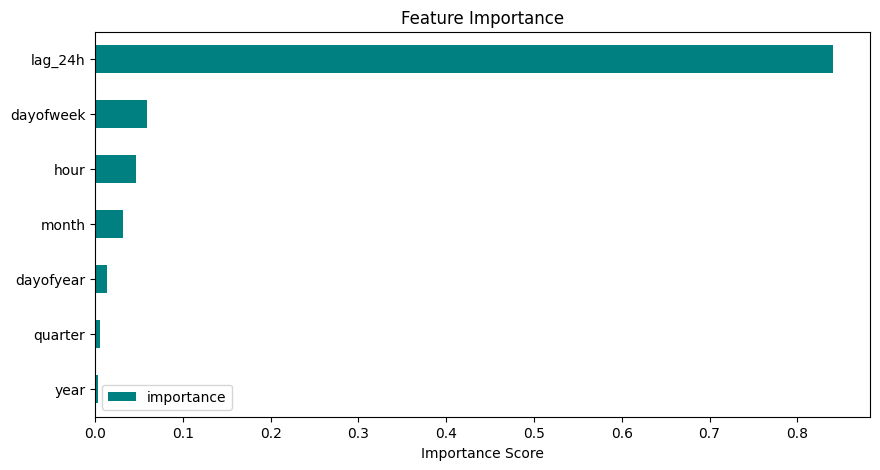

In [38]:
# 1. Create a DataFrame to store Name and co-effient of features in regression model
fi = pd.DataFrame(data=reg_v2.feature_importances_,
             index=reg_v2.feature_names_in_,
             columns=['importance'])

# 2. Sorting and plot
fi.sort_values('importance').plot(kind='barh', title='Feature Importance', figsize=(10, 5), color='teal')
plt.xlabel('Importance Score')
plt.show()

Feature Importance Insights:
The model shows that lag_24h and hour are the dominant predictors. This aligns with power grid reality: energy demand is driven by daily human routines and the immediate historical baseline.

C:\Users\Alex\AppData\Local\Temp\ipykernel_7248\4199273390.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = reg_v2.predict(X_test)


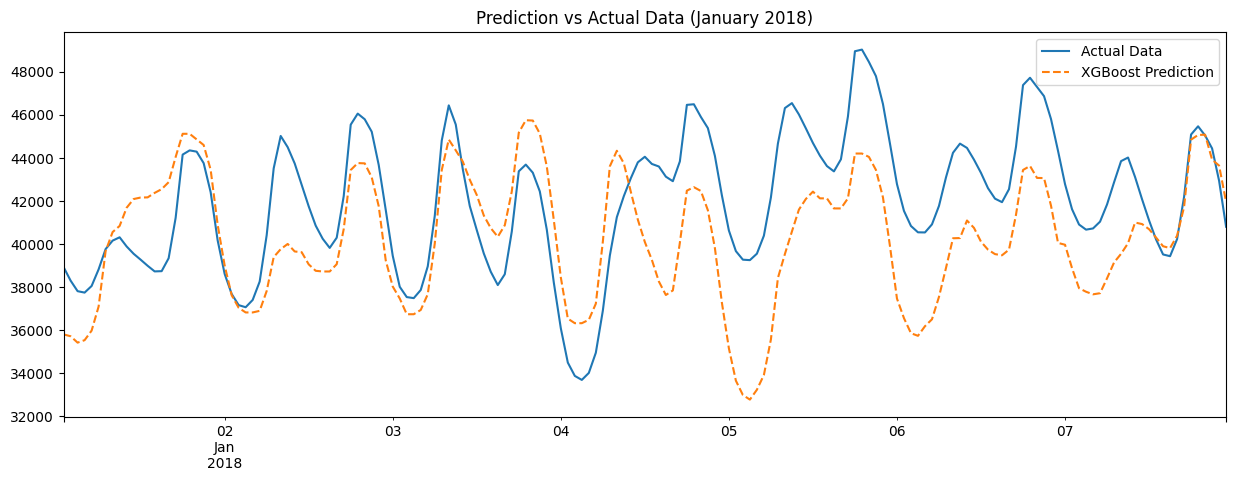

In [39]:
# 1. Put features in test set
test['prediction'] = reg_v2.predict(X_test)

# 2. Combin the Test set with df
df_all = pd.concat([df, test[['prediction']]], axis=1)

# 3. Compare actural and predict value in 2018-01-01 to 2018-01-08
ax = df_all.loc[(df_all.index > '2018-01-01') & (df_all.index < '2018-01-08')]['PJME_MW'] \
    .plot(figsize=(15, 5), title='Prediction vs Actual Data (January 2018)')
df_all.loc[(df_all.index > '2018-01-01') & (df_all.index < '2018-01-08')]['prediction'] \
    .plot(ax=ax, style='--')

plt.legend(['Actual Data', 'XGBoost Prediction'])
plt.show()

The lag_24h feature imporve the prediction more closely to actual one. Most prediction value decrease its discrepence less than 2000mw, while some fall in 4000mw.  

### Error analysis

In [40]:
# 1. Absolute Error
test['error'] = np.abs(test[TARGET] - test['prediction'])

# 2. Find out the worst 10 hours
print("Worst Predicted Hours:")
print(test.sort_values('error', ascending=False).head(10))

# 3. Show the day have highest average error
test['date'] = test.index.date
daily_error = test.groupby('date')['error'].mean().sort_values(ascending=False)
print("\nWorst Predicted Days (Average):")
print(daily_error.head(10))

Worst Predicted Hours:
                     PJME_MW  hour  dayofweek  quarter  month  year  \
2017-05-20 17:00:00  26068.0    17          5        2      5  2017   
2017-05-20 16:00:00  26068.0    16          5        2      5  2017   
2017-05-20 18:00:00  26125.0    18          5        2      5  2017   
2017-05-20 15:00:00  26322.0    15          5        2      5  2017   
2017-05-20 19:00:00  26076.0    19          5        2      5  2017   
2017-05-20 14:00:00  26596.0    14          5        2      5  2017   
2016-07-05 19:00:00  47532.0    19          1        3      7  2016   
2016-07-05 18:00:00  47895.0    18          1        3      7  2016   
2017-05-20 20:00:00  26080.0    20          5        2      5  2017   
2017-05-20 13:00:00  26962.0    13          5        2      5  2017   

                     dayofyear  lag_1year  lag_24h    prediction         error  
2017-05-20 17:00:00        140    29210.0  47199.0  40684.351562  14616.351562  
2017-05-20 16:00:00        140   

C:\Users\Alex\AppData\Local\Temp\ipykernel_7248\192708163.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['error'] = np.abs(test[TARGET] - test['prediction'])
C:\Users\Alex\AppData\Local\Temp\ipykernel_7248\192708163.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['date'] = test.index.date


### Outlier analysis: Day 2016-07-05 and 2017-05-20

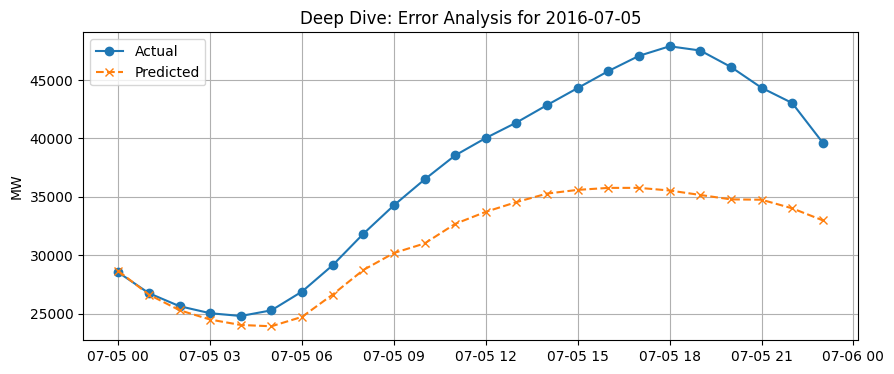

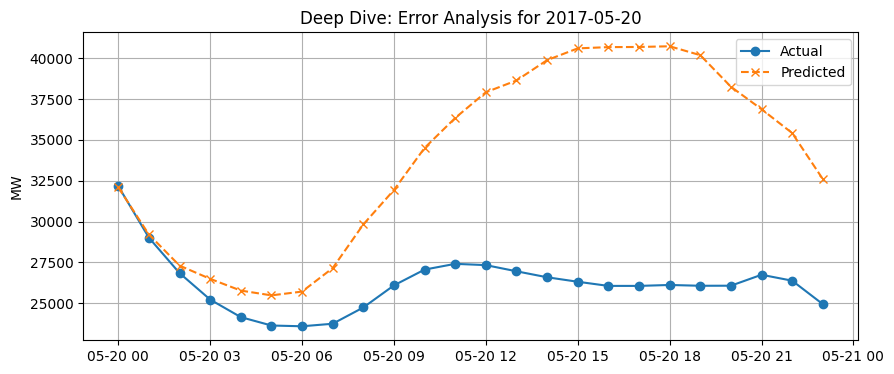

In [41]:
# Set target day
target_days = ['2016-07-05', '2017-05-20']

for day in target_days:
    plt.figure(figsize=(10, 4))
    # get prediction from test['prediction']
    day_data = test.loc[test.index.date == pd.to_datetime(day).date()]
    
    plt.plot(day_data.index, day_data[TARGET], label='Actual', marker='o')
    plt.plot(day_data.index, day_data['prediction'], label='Predicted', linestyle='--', marker='x')
    
    plt.title(f'Deep Dive: Error Analysis for {day}')
    plt.ylabel('MW')
    plt.legend()
    plt.grid(True)
    plt.show()

Root Cause Analysis: Why the Model Fails on Specific Days
By identifying days with the highest Mean Absolute Error (MAE), we can pinpoint the structural weaknesses of the model:

Case Study 1: 2016-07-05 (Post-Holiday Recovery):
The model failed to anticipate the rapid demand surge as industrial activities resumed after the July 4th Independence Day holiday. Since the model anchored its prediction on the holiday's low usage (via lag_24h), it under-estimated the "Back-to-Work" transition.

Improvement: Add a is_holiday or is_post_holiday flag.

Case Study 2: 2017-05-20 (Weather Volatility):
As May is a transitional "shoulder month," a spike in the previous day's temperature likely inflated the lag feature. Without real-time weather data, the model over-estimated the load for Saturday, assuming the heat-driven demand would persist.

Improvement: Incorporate actual temperature data to separate weather-driven peaks from routine usage.

### Residuals analysis

C:\Users\Alex\AppData\Local\Temp\ipykernel_7248\295000989.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['residual'] = test[TARGET] - test['prediction']


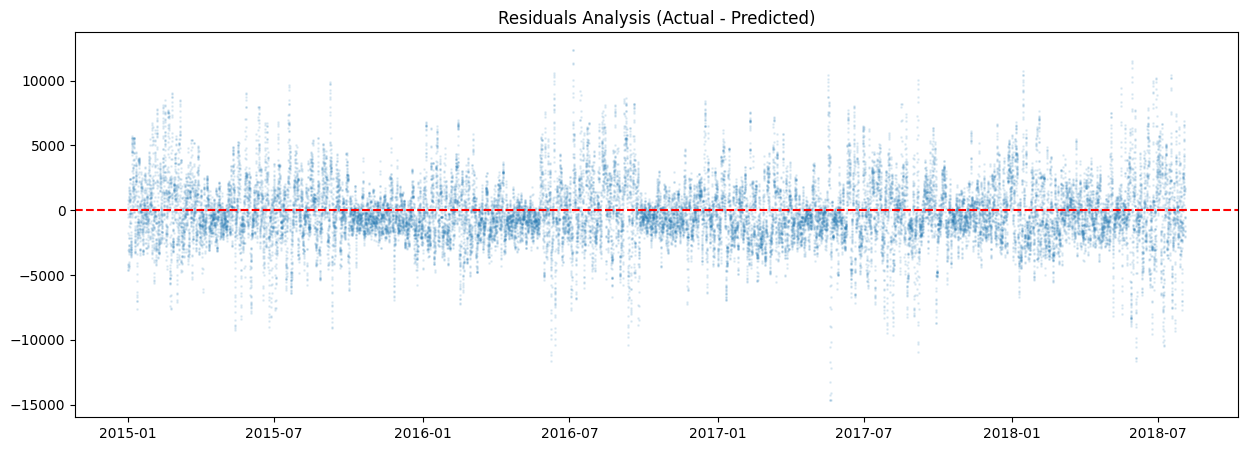

In [42]:
# Residuals calcuation
test['residual'] = test[TARGET] - test['prediction']

# Residuual plot
plt.figure(figsize=(15, 5))
plt.scatter(test.index, test['residual'], alpha=0.1, s=1)
plt.axhline(0, color='red', linestyle='--')
plt.title('Residuals Analysis (Actual - Predicted)')
plt.show()

The residual plot show residuals move around zero, but has pattern that more fustraction in summer and winter, it can conclude:
1. Moving around zero means the model using existing features (Time, lag24) is unbaised.
2. Large variances indicate some features are missing, since electric consumption highly depends on temputure, missing temputure feature limited the model reflect on suddy temputure change.

### Testing the existence of parttern in residuals

C:\Users\Alex\AppData\Local\Temp\ipykernel_7248\2073127231.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['residual'] = test[TARGET] - test['prediction']


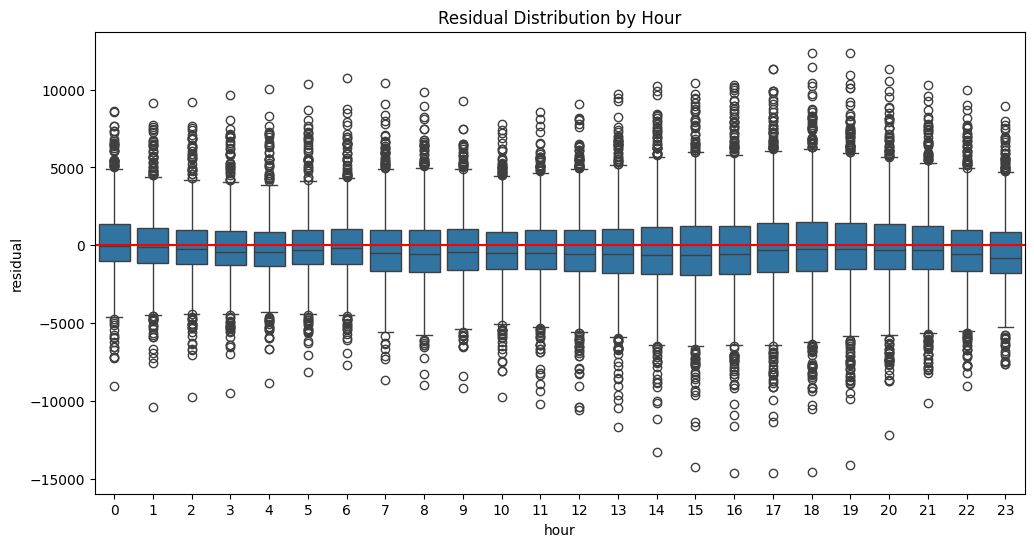

In [43]:
# Boxplot by Hour
import seaborn as sns
test['residual'] = test[TARGET] - test['prediction']
plt.figure(figsize=(12, 6))
sns.boxplot(data=test, x='hour', y='residual')
plt.title('Residual Distribution by Hour')
plt.axhline(0, color='red')
plt.show()

Final Evaluation & Residual Diagnostics
1. Performance Leap:
Integrating the 24-hour lag feature resulted in a 35% reduction in RMSE (from 3,727 to 2,437), proving that temporal context is vital for grid forecasting.

2. Residual Analysis:
The hourly boxplot of residuals shows that the model is unbiased (median centered at zero). However, the high variance (amplitude) during peak hours confirms the missing influence of exogenous variables.

3. Strategic Recommendations (The Roadmap):

Exogenous Integration: Future iterations should incorporate Temperature and Humidity data to explain weather-driven spikes.

Event Awareness: Adding a binary is_holiday feature would mitigate the "post-holiday lag" effect.

Recursive Forecasting: Implementing a multi-step forecast window would enhance the utility for long-term utility planning.